In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("../data/raw/TPD_OPEN_DATA_ReportedCrimesPublicDash.csv", low_memory = False)
df.shape

(251280, 14)

In [22]:
def parse_time_occur(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().replace(":", "").zfill(4)
    if s.startswith("24"):
        return 0
    try:
        hour = int(s[:2])
        minute = int(s[2:])
        if 0 <= hour <= 23 and 0 <= minute <= 59:
            return hour
        else:
            return np.nan
    except ValueError:
        return np.nan

df["Hour"] = df["TimeOccur"].apply(parse_time_occur)

print(f"Parsed successfully: {df['Hour'].notna().sum()}")
print(f"Failed to parse: {df['Hour'].isna().sum()}")

Parsed successfully: 251280
Failed to parse: 0


In [23]:
print(df["Hour"].value_counts().sort_index())

Hour
0     13630
1      4954
2      4577
3      4078
4      3837
5      3920
6      4382
7      5786
8      8762
9      9905
10    13071
11    12862
12    15793
13    13738
14    14627
15    14782
16    14762
17    15147
18    14693
19    14018
20    13481
21    12070
22     9987
23     8418
Name: count, dtype: int64


In [24]:
df.isnull().sum()

IncidentID                0
DateOccurred              0
Year                      0
Month                     0
Day                       0
TimeOccur                 0
Division               3743
Ward                  15566
UCR                       0
UCRDescription            0
Offense                   0
OffenseDescription        0
CallSource             7408
ESRI_OID                  0
Hour                      0
dtype: int64

In [25]:
# dropping 2026 data as it is incomplete
df = df[df["Year"] != 2026]

# dropping rows where Division is missing 
df = df.dropna(subset=["Division"])
df = df[df["Division"] != "Other Jurisdiction"]

# filling Ward and CallSource 
df["Ward"] = df["Ward"].fillna(0).astype(str)
df["CallSource"] = df["CallSource"].fillna("Unknown")

# converting Hour to int
df["Hour"] = df["Hour"].astype(int)

# dropping columns we no longer need
df = df.drop(columns=["TimeOccur", "ESRI_OID", "DateOccurred"])

print(f"Final shape: {df.shape}")
print(df.isnull().sum())

Final shape: (243127, 12)
IncidentID            0
Year                  0
Month                 0
Day                   0
Division              0
Ward                  0
UCR                   0
UCRDescription        0
Offense               0
OffenseDescription    0
CallSource            0
Hour                  0
dtype: int64


In [29]:
df.to_csv("../data/processed/tpd_2018_2025.csv", index = False)
print("Saved.")

Saved.


In [30]:
df_clean = pd.read_csv("../data/processed/tpd_2018_2025.csv")

print(df_clean.shape)
print(df_clean.dtypes)
print(df_clean["Hour"].value_counts().sort_index())
print(df_clean["UCRDescription"].value_counts())

(243127, 12)
IncidentID             object
Year                    int64
Month                  object
Day                    object
Division               object
Ward                  float64
UCR                     int64
UCRDescription         object
Offense                 int64
OffenseDescription     object
CallSource             object
Hour                    int64
dtype: object
Hour
0     13172
1      4756
2      4401
3      3940
4      3713
5      3805
6      4237
7      5628
8      8515
9      9594
10    12647
11    12488
12    15300
13    13317
14    14196
15    14250
16    14268
17    14600
18    14182
19    13517
20    13018
21    11702
22     9696
23     8185
Name: count, dtype: int64
UCRDescription
06 - LARCENY                170264
05 - BURGLARY                21409
07 - GTA                     19227
04 - ASSAULT, AGGRAVATED     18465
03 - ROBBERY                  8188
02 - SEXUAL ASSAULT           3534
08 - ARSON                    1512
01 - HOMICIDE                  528

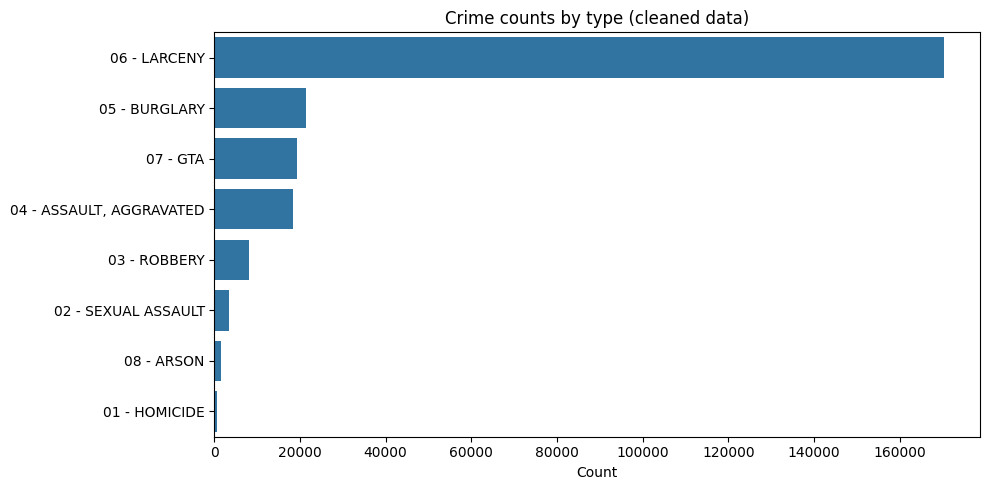

In [31]:
plt.figure(figsize=(10, 5))
order = df_clean["UCRDescription"].value_counts().index
sns.countplot(data=df_clean, y="UCRDescription", order=order)
plt.title("Crime counts by type (cleaned data)")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

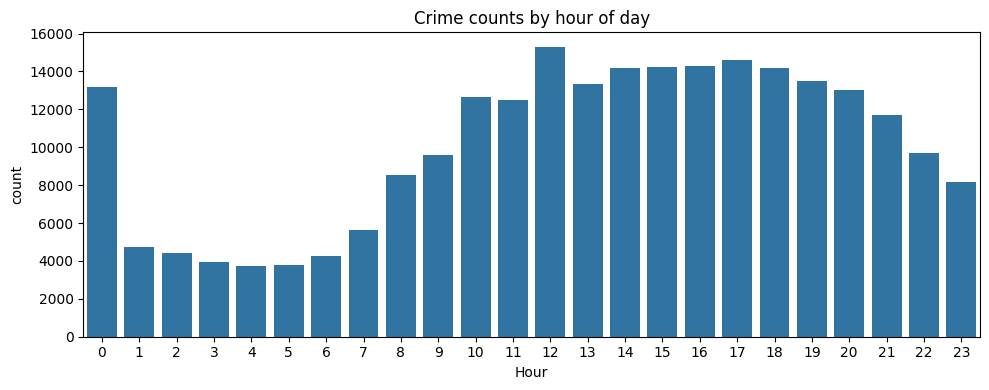

In [32]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df_clean, x="Hour")
plt.title("Crime counts by hour of day")
plt.tight_layout()
plt.show()

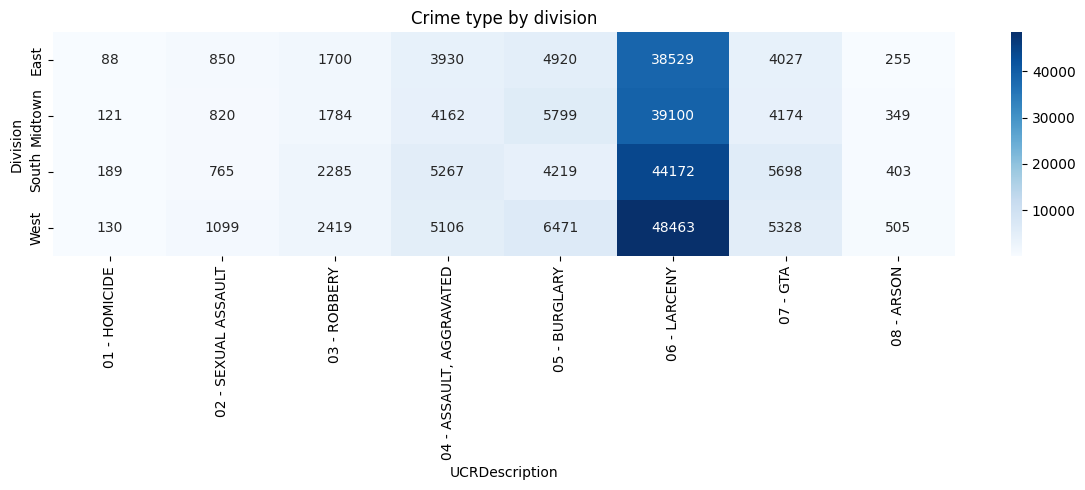

In [33]:
pivot = df_clean.groupby(["Division", "UCRDescription"]).size().unstack(fill_value=0)
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Crime type by division")
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

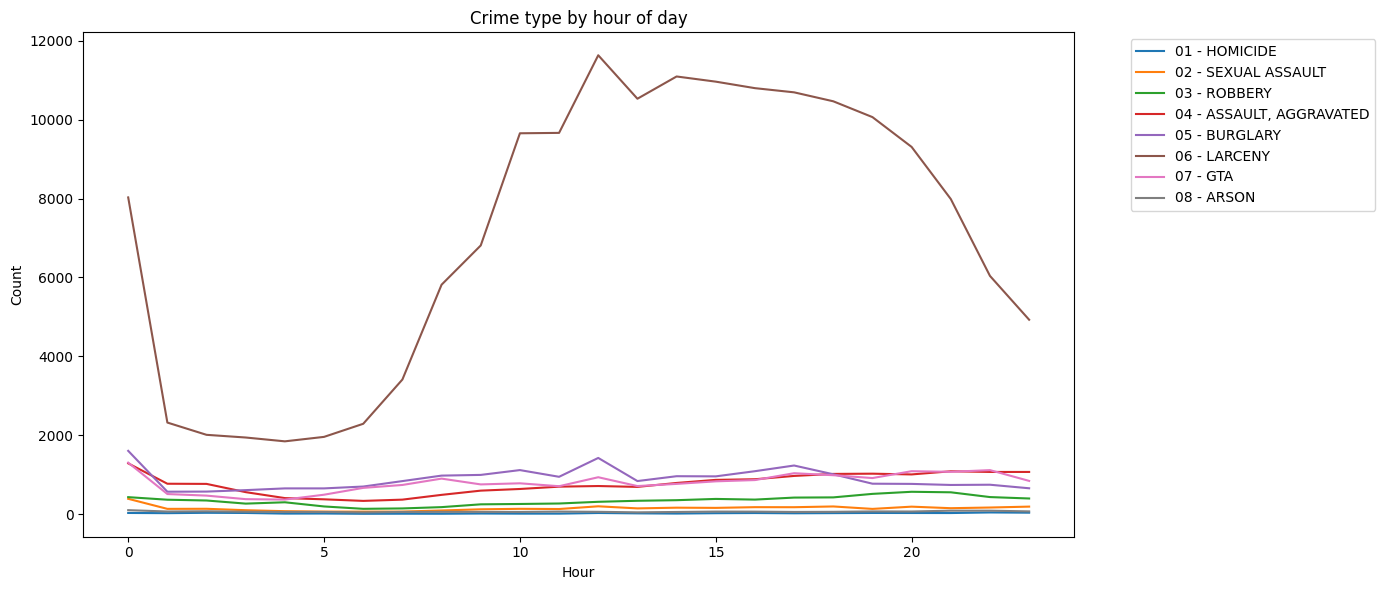

In [34]:
plt.figure(figsize=(14, 6))
pivot = df_clean.groupby(["Hour", "UCRDescription"]).size().unstack(fill_value=0)
pivot.plot(kind="line", figsize=(14, 6))
plt.title("Crime type by hour of day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()